In [123]:
import warnings
from copy import deepcopy
warnings.filterwarnings("ignore")
import logging
from statkit.decision import NetBenefitDisplay
import scipy
from sklearn.metrics import * 
import pandas as pd
import seaborn as sns
import numpy as np
import shap
import torch
import os
import inspect 
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle
from numpy import sqrt
from numpy import argmax
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from matplotlib import pyplot
from torchinfo import summary as torchsummary
from torchvision import models, transforms
from model import init_model
from matplotlib import pyplot
from pathlib import Path
sns.set(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999




In [4]:
ROOT_DIR = Path(os.path.dirname(os.path.abspath('')))
TOTAL_TRAIN_SAMPLES = 50
TOTAL_TEST_SAMPLES = 10
CHANNELS = 3
DEVICE = "cuda:1"
OCT_PRESENCE = "Usando OCT"
DUAL_IMAGE = "Dual Image"
DATA_PATH = "../data.csv"
SUMMARY_PATH = "../model_summary.csv"
HISTORY_PATH = "../history.csv"
FT_SIZE = 24
ARQ1 = "SI"
ARQ2 = "SIT"
ARQ3 = "DI"
ARQ4 = "DIT"

In [77]:
def get_samples_from_loader(loader, size):
    """
    Return photos1, photos2, ft_numerical, labels
    """

    list_of_photos_1 = []
    list_of_photos_2 = []
    list_of_features = []
    list_of_labels = []

    for photos1, photos2, numericalft, labels in loader:
        for i in range(len(labels)):
            list_of_photos_1.append(photos1[i])
            list_of_photos_2.append(photos2[i])
            list_of_features.append(numericalft[i])
            list_of_labels.append(labels[i].numpy())

            if len(list_of_labels) >= size:
                break

        if len(list_of_labels) >= size:
            break

    photos1 = torch.stack(list_of_photos_1)
    photos2 = torch.stack(list_of_photos_2)
    ft_numerical = torch.stack(list_of_features)
    labels = np.array(list_of_labels)

    return (photos1, photos2, ft_numerical, labels)


In [6]:
def load_model_and_loaders(model_row):
    """
        Return model, train_loader, val_loader
    """ 
    model_name = model_row["backbone"].values[0]
    pretrained = False
    feature_extract = False
    double_img_bool = True if model_row["double_img"].values[0] > 0 else False
    output_tab = int(model_row["output_tab"].values[0]) if model_row["output_tab"].values[0] > 0 else None 
    model, input_size = init_model(model_name,pretrained, feature_extract, double_img_bool, output_tab, FT_SIZE)
    model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + "model"+ ".pth"))
    train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader" + ".pth")
    val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader" + ".pth")
    
    val_loader.dataset.root_dir = ROOT_DIR
    train_loader.dataset.root_dir = ROOT_DIR
    
    return model, train_loader, val_loader, input_size

In [7]:
def create_explainers(model, device, photos1_train, photos2_train, ft_numerical_train, 
                                     photos1_val, photos2_val, ft_numerical_val, input_size):
    """
        Return shap_values_photo1, shap_values_photo2, shap_values_nuermical
    """ 
    
    model = model.to(device)
    explainer = shap.DeepExplainer(model, [photos1_train.to(device),photos2_train.to(device),ft_numerical_train.to(device)])
    shap_values_photo1, shap_values_photo2, shap_values_numerical = explainer.shap_values([photos1_val.to(device),photos2_val.to(device), ft_numerical_val.to(device)])
    
    photos1_list = []
    photos2_list = []
    for i in range(len(photos1_val)):
        photos1_list.append(imshow(photos1_val[i]))
        photos2_list.append(imshow(photos2_val[i]))
        
    
    photos1_numpy = np.asarray(photos1_list)
    photos2_numpy = np.asarray(photos2_list)
    
    return (shap_values_photo1.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_photo2.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_numerical,
            photos1_numpy, 
            photos2_numpy)

In [8]:
def plot_image(shap_values, photos, total):
    
    return shap.image_plot(shap_values[:total], photos[:total])

In [9]:
def imshow(image):
    npimg = image.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = ((npimg * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    return npimg

In [10]:
def shapley_feature_ranking(shap_values):
    feature_order = np.argsort(np.mean(np.abs(shap_values), axis=0))
    return pd.DataFrame(
        {
            "features": [features_name[i] for i in feature_order][::-1],
            "importance": [
                np.mean(np.abs(shap_values), axis=0)[i] for i in feature_order
            ][::-1],
        }
    )

In [11]:
def get_rank_per_group(df_max,df_avg):
    dict_rows = {}
    dict_rows["Backbone"] = []
    dict_rows[OCT_PRESENCE] = []
    dict_rows[DUAL_IMAGE] = []
    dict_rows["Max Auc Rank"] = []
    dict_rows["Avg Auc Rank"] = []
 
 
    df_max = df_max.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    df_avg = df_avg.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    
    
    for index, row in df_max.iterrows():
        dict_rows["Backbone"].append(row["backbone"])
        dict_rows[OCT_PRESENCE].append(row[OCT_PRESENCE])
        dict_rows[DUAL_IMAGE].append(row[DUAL_IMAGE])
        dict_rows["Max Auc Rank"].append(row["rank_max_auc_oct_double"])
        
    for index, row in df_avg.iterrows():
        dict_rows["Avg Auc Rank"].append(row["rank_avg_auc_oct_double"])
        
    df_rank_per_group = pd.DataFrame.from_dict(dict_rows)
    return df_rank_per_group

In [128]:
def get_numpy(val_loader):
    photos1_val, photos2_val, ft_numerical_val, labels_val =  get_samples_from_dataloader(val_loader, len(val_loader.dataset))
    photos1_list = []
    photos2_list = []
    photos1_list_non_inv = []
    photos2_list_non_inv = []
    for i in range(len(photos1_val)):
        photos1_list.append(imshow(photos1_val[i]))
        photos2_list.append(imshow(photos2_val[i]))
        photos1_list_non_inv.append(deepcopy(photos1_val[i]))
        photos2_list_non_inv.append(deepcopy(photos2_val[i]))


    photos1_numpy = np.asarray(photos1_list)
    photos2_numpy = np.asarray(photos2_list)
    photos1_numpy_non_inv = np.asarray(photos1_list_non_inv)
    photos2_numpy_non_inv = np.asarray(photos2_list_non_inv)
    return photos1_numpy, photos2_numpy, photos1_numpy_non_inv, photos2_numpy_non_inv

In [12]:
data = pd.read_csv(DATA_PATH)
summary = pd.read_csv(SUMMARY_PATH)
filter_summary = pd.read_csv("../filter_top1.csv")
df_peak = pd.read_csv("../df_peak_mem_summary.csv")
history = pd.read_csv(HISTORY_PATH)

important_columns = ['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc','host_name', 'optim', 'lr', 'scheduler',
       'randaugop', 'epochs', 'double_img', 'output_tab', 'backbone',
       'early_start', 'patient_el','oos_best_auc',
       'avg_best_auc_oos','std_val_auc', 'std_oos_auc',
       'inference_time', 'avg_best_auc_val', 'max_sp_oos', 'max_sn_oos',
       'idx_max_sp_val', 'idx_max_sn_val', 'idx_avg_sp_val', 'idx_avg_sn_val',
       'avg_sp_oos', 'avg_sn_oos', 'std_sn_oos', 'std_sp_oos',
       'idx_std_sn_val', 'idx_std_sp_val']

## Compare one image nad two images 

In [14]:
model_1 = "785ed10d4c6e4f71bb6b36db16f64b2d" 
model_2 = "a50e719c914f4e07a6dc5fe36c191780"

In [25]:
history_filtered = history[history["model_id"] == model_2]
history_filtered.sort_values("val_auc_history",ascending=False)

,epochs,iter,train_acc_history,train_auc_history,train_loss_history,train_sensitivity_history,train_specificity_history,val_acc_history,val_auc_history,val_loss_history,val_sensitivity_history,val_specificity_history,backbone,Usando OCT,Dual Image,optim,lr,frac_val,k_fold,model_id,lr_history
48737,59,1,0.917492,0.879803,121.868048,0.787709,0.971897,0.907895,0.898804,37.416758,0.882353,0.915254,regnet16x,NaN,NaN,radam,0.001,NaN,5.0,a50e719c914f4e07a6dc5fe36c191780,1.000000e-08
48769,91,1,0.930693,0.903772,111.428831,0.837989,0.969555,0.907895,0.898804,43.314628,0.882353,0.915254,regnet16x,NaN,NaN,radam,0.001,NaN,5.0,a50e719c914f4e07a6dc5fe36c191780,1.000000e-08
48697,19,1,0.896040,0.853224,166.216491,0.748603,0.957845,0.907895,0.888335,38.888897,0.852941,0.923729,regnet16x,NaN,NaN,radam,0.001,NaN,5.0,a50e719c914f4e07a6dc5fe36c191780,1.000000e-04
48702,24,1,0.902640,0.862775,141.492870,0.765363,0.960187,0.921053,0.886341,35.390196,0.823529,0.949153,regnet16x,NaN,NaN,radam,0.001,NaN,5.0,a50e719c914f4e07a6dc5fe36c191780,1.000000e-04
48774,96,1,0.930693,0.911884,115.692554,0.865922,0.957845,0.901316,0.884098,42.771539,0.852941,0.915254,regnet16x,NaN,NaN,radam,0.001,NaN,5.0,a50e719c914f4e07a6dc5fe36c191780,1.000000e-08
48719,41,1,0.920792,0.888634,114.383121,0.810056,0.967213,0.901316,0.884098,39.720720,0.852941,0.915254,regnet16x,NaN,NaN,radam,0.001,NaN,5.0,a50e719c914f4e07a6dc5fe36c191780,1.000000e-06
48752,74,1,0.932343,0.903321,102.287670,0.832402,0.974239,0.901316,0.884098,41.773201,0.852941,0.915254,regnet16x,NaN,NaN,radam,0.001,NaN,5.0,a50e719c914f4e07a6dc5fe36c191780,1.000000e-08
48753,75,1,0.933993,0.912603,95.222929,0.860335,0.964871,0.914474,0.882104,40.935366,0.823529,0.940678,regnet16x,NaN,NaN,radam,0.001,NaN,5.0,a50e719c914f4e07a6dc5fe36c191780,1.000000e-08
48743,65,1,0.924092,0.892599,117.344010,0.815642,0.969555,0.894737,0.879860,42.485258,0.852941,0.906780,regnet16x,NaN,NaN,radam,0.001,NaN,5.0,a50e719c914f4e07a6dc5fe36c191780,1.000000e-08
48730,52,1,0.929043,0.896112,117.689913,0.815642,0.976581,0.894737,0.879860,45.567448,0.852941,0.906780,regnet16x,NaN,NaN,radam,0.001,NaN,5.0,a50e719c914f4e07a6dc5fe36c191780,1.000000e-08


In [43]:
summary[summary["model_id"].isin([model_1,model_2])]

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,oos_best_auc,avg_best_auc_oos,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,std_val_auc,std_oos_auc,inference_time,avg_best_auc_val,max_sp_oos,max_sn_oos,idx_max_sp_val,idx_max_sn_val,idx_avg_sp_val,idx_avg_sn_val,avg_sp_oos,avg_sn_oos,std_sn_oos,std_sp_oos,idx_std_sn_val,idx_std_sp_val
377,785ed10d4c6e4f71bb6b36db16f64b2d,NaN,0.2,0.878981,0.851841,1.00000,0.847826,0.814395,0.761933,0.888649,0.635217,0.991681,0.988714,1.000000,0.982036,0.943145,0.916132,0.976935,0.855329,magneto,radam,0.0001,NaN,0,100.0,1.0,0.0,mobile,100.0,10.0,2022-11-06 18:49:39.800222,04:51:53.69,04:51:53.69,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,Não,Sim,other,other,234.0,208.0,NaN,NaN,1.0,2.0,111.25,NaN,NaN,NaN,NaN,NaN,NaN,0.855856,0.847826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
858,a50e719c914f4e07a6dc5fe36c191780,5.0,NaN,0.921053,0.898804,0.99115,0.957447,0.816615,0.758205,0.894366,0.622044,0.947195,0.931705,0.993151,0.893855,0.901829,0.858910,0.956714,0.761106,magneto,radam,0.0010,plateau,0,100.0,0.0,0.0,regnet16x,30.0,10.0,2022-12-17 23:05:14.946199,38:31:58.42,07:42:23.59,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.73564,0.682723,NaN,NaN,NaN,0.052274,0.040079,0.044,0.817663,0.895522,0.575758,0.929204,0.882353,0.913449,0.721877,0.880597,0.484848,0.081312,0.018879,0.107057,0.009294


In [29]:
with open(r"../models/785ed10d4c6e4f71bb6b36db16f64b2d/model_balanced_shap_values_dict_val.pkl", "rb") as f:
    shap_model_1 = pickle.load(f)
    
with open(r"../models/a50e719c914f4e07a6dc5fe36c191780/model_fold_1_balanced_shap_values_dict_val.pkl", "rb") as f:
    shap_model_2 = pickle.load(f)
    
val_loader_1  = torch.load("../models/785ed10d4c6e4f71bb6b36db16f64b2d/val_dataloader" + ".pth")
val_loader_2  = torch.load("../models/a50e719c914f4e07a6dc5fe36c191780/val_dataloader" + "_fold_1.pth")


In [54]:
dataset_1_df = val_loader_1.dataset.glaucoma_data
dataset_2_df = val_loader_2.dataset.glaucoma_data

In [68]:
dataset_1_df

,Patient,label,photo_1,photo_2,eye_side,gender,G,T,TS,NS,N,NI,TI,age,T/TS,T/NS,T/N,T/NI,T/TI,TS/NS,TS/N,TS/NI,TS/TI,NS/N,NS/NI,NS/TI,N/NI,N/TI,NI/TI
1,ADAO A SENA 1017456,1,imgs/ADAO A SENA 1017456/111111_Color_11MP_R_0...,imgs/ADAO A SENA 1017456/111111_Color_11MP_R_0...,right,1.0,-0.035088,-0.009259,0.125000,0.171429,0.102362,0.027933,-0.039409,0.623656,0.046339,0.077188,0.127389,0.165165,0.459654,0.251575,0.319408,0.354266,0.391359,0.476472,0.481582,0.599632,0.436081,0.416181,0.464185
7,ADAO P SILVA 00936976,1,imgs/ADAO P SILVA 00936976/111111_Color_11MP_R...,imgs/ADAO P SILVA 00936976/111111_Color_11MP_R...,right,1.0,0.377193,0.296296,0.268519,0.377143,0.448819,0.435754,0.394089,0.655914,0.087550,0.152098,0.105364,0.096650,0.112578,0.245060,0.178905,0.172173,0.103967,0.197257,0.230233,0.149821,0.369732,0.166742,0.214177
11,ADELINA MARIA SOUZA BORGES 00575950,0,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,right,0.0,0.552632,0.444444,0.527778,0.577143,0.401575,0.508380,0.576355,0.903226,0.052209,0.128208,0.177418,0.132805,0.102840,0.313391,0.383980,0.291515,0.142933,0.456369,0.311623,0.162588,0.281177,0.089522,0.161847
12,ADELINA MARIA SOUZA BORGES 00575950,0,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,left,0.0,0.526316,0.361111,0.527778,0.651429,0.346457,0.530726,0.536946,0.903226,0.040161,0.079855,0.173695,0.090090,0.083126,0.278121,0.438703,0.280887,0.152287,0.639260,0.340130,0.199277,0.227001,0.079398,0.186926
33,ALMIR FRANCISCO SANTOS 166892,0,imgs/ALMIR FRANCISCO SANTOS 166892/111111_Colo...,imgs/ALMIR FRANCISCO SANTOS 166892/111111_Colo...,right,1.0,0.596491,0.509259,0.430556,0.382857,0.913386,0.379888,0.428571,0.559140,0.081928,0.253708,0.064864,0.232975,0.202387,0.377998,0.135379,0.304085,0.151793,-0.008022,0.265398,0.140179,0.873897,0.349451,0.166139
34,ALMIR FRANCISCO SANTOS 166892,1,imgs/ALMIR FRANCISCO SANTOS 166892/111111_Colo...,imgs/ALMIR FRANCISCO SANTOS 166892/111111_Colo...,left,1.0,0.456140,0.509259,0.361111,0.411429,0.464567,0.290503,0.472906,0.559140,0.102276,0.233364,0.170699,0.309465,0.176307,0.298914,0.230781,0.315766,0.117588,0.216802,0.357317,0.137190,0.543453,0.141786,0.104258
35,ANA C REIS 00828511,1,imgs/ANA C REIS 00828511/111111_Color_11MP_R_0...,imgs/ANA C REIS 00828511/111111_Color_11MP_R_0...,right,0.0,0.535088,0.333333,0.254630,0.594286,0.692913,0.541899,0.472906,0.709677,0.103339,0.085220,0.060633,0.075321,0.095172,0.147349,0.105927,0.133889,0.084021,0.200654,0.302667,0.204132,0.480345,0.231611,0.222889
43,ANA MARIA CARVALHO SANTOS 11029279,1,imgs/ANA MARIA CARVALHO SANTOS 11029279/111111...,imgs/ANA MARIA CARVALHO SANTOS 11029279/111111...,left,0.0,0.298246,0.185185,0.083333,0.451429,0.566929,0.586592,-0.014778,0.741935,0.190361,0.070103,0.043718,0.006930,0.814717,0.070483,0.042721,0.040431,0.227045,0.174713,0.207866,1.017898,0.357044,1.311061,1.786191
50,ANALICE SANTOS NASCIMENTO,0,imgs/ANALICE SANTOS NASCIMENTO/111111_Color_11...,imgs/ANALICE SANTOS NASCIMENTO/111111_Color_11...,right,0.0,0.482456,0.481481,0.509259,0.497143,0.377953,0.251397,0.551724,0.645161,0.060768,0.173618,0.204560,0.334620,0.127090,0.349161,0.391941,0.484252,0.143495,0.402701,0.479786,0.144138,0.494112,0.087095,0.064252
52,ANDREIA ALVES FREITAS 10809366,0,imgs/ANDREIA ALVES FREITAS 10809366/111111_Col...,imgs/ANDREIA ALVES FREITAS 10809366/111111_Col...,right,0.0,0.622807,0.675926,0.648148,0.560000,0.472441,0.368715,0.546798,0.440860,0.064151,0.216155,0.221509,0.330165,0.208900,0.395727,0.404282,0.462964,0.183606,0.349004,0.401029,0.165970,0.453937,0.121311,0.114706


In [69]:
dataset_2_df

,Patient,label,photo_1,photo_2,eye_side,gender,G,T,TS,NS,N,NI,TI,age,T/TS,T/NS,T/N,T/NI,T/TI,TS/NS,TS/N,TS/NI,TS/TI,NS/N,NS/NI,NS/TI,N/NI,N/TI,NI/TI
5,ADAO MOREIRA SOUZA 01025453,0,imgs/ADAO MOREIRA SOUZA 01025453/111111_Color_...,imgs/ADAO MOREIRA SOUZA 01025453/111111_Color_...,right,1.0,0.689655,0.458716,0.716763,0.600000,0.685039,0.644578,0.502370,0.580645,0.140835,0.121120,0.090026,0.139436,0.145825,0.328346,0.254294,0.283591,0.147229,0.215417,0.275584,0.198655,0.459761,0.170609,0.137828
6,ADAO MOREIRA SOUZA 01025453,0,imgs/ADAO MOREIRA SOUZA 01025453/111111_Color_...,imgs/ADAO MOREIRA SOUZA 01025453/111111_Color_...,left,1.0,0.706897,0.422018,0.676301,0.491429,0.763780,0.753012,0.521327,0.580645,0.137214,0.147940,0.067904,0.084461,0.120289,0.388637,0.209492,0.227191,0.129266,0.107482,0.188227,0.153938,0.444494,0.186091,0.157057
11,ADELINA MARIA SOUZA BORGES 00575950,0,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,right,0.0,0.577586,0.449541,0.554913,0.577143,0.401575,0.542169,0.592417,0.903226,0.201394,0.125517,0.177418,0.181647,0.102840,0.261328,0.356489,0.261663,0.077942,0.460695,0.311623,0.159729,0.302171,0.068282,0.090610
12,ADELINA MARIA SOUZA BORGES 00575950,0,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,left,0.0,0.551724,0.366972,0.554913,0.651429,0.346457,0.566265,0.554502,0.903226,0.154919,0.077015,0.173695,0.123223,0.083126,0.223383,0.413654,0.250588,0.088006,0.642130,0.340130,0.195773,0.243951,0.060560,0.104651
15,AIDE APARECIDA GONZAGA AMBROSIO 10875110,0,imgs/AIDE APARECIDA GONZAGA AMBROSIO 10875110/...,imgs/AIDE APARECIDA GONZAGA AMBROSIO 10875110/...,right,0.0,0.655172,0.532110,0.618497,0.537143,0.543307,0.584337,0.606635,0.548387,0.215529,0.170692,0.146268,0.205872,0.129717,0.320058,0.285672,0.270110,0.088866,0.267567,0.269059,0.143594,0.392231,0.101270,0.096213
16,AIDE APARECIDA GONZAGA AMBROSIO 10875110,0,imgs/AIDE APARECIDA GONZAGA AMBROSIO 10875110/...,imgs/AIDE APARECIDA GONZAGA AMBROSIO 10875110/...,left,0.0,0.663793,0.440367,0.658960,0.794286,0.503937,0.608434,0.511848,0.548387,0.152337,0.067859,0.132044,0.145054,0.132853,0.208371,0.330231,0.276239,0.128225,0.527310,0.392380,0.262477,0.346515,0.114440,0.126166
44,ANA MARIA MERENCIANO,0,imgs/ANA MARIA MERENCIANO/111111_Color_11MP_R_...,imgs/ANA MARIA MERENCIANO/111111_Color_11MP_R_...,right,0.0,0.482759,0.321101,0.364162,0.354286,0.535433,0.548193,0.473934,0.698925,0.229879,0.172285,0.086935,0.104792,0.094661,0.306517,0.172598,0.172549,0.060377,0.122130,0.182719,0.119496,0.410700,0.135628,0.123309
45,ANA MARIA MERENCIANO,0,imgs/ANA MARIA MERENCIANO/111111_Color_11MP_L_...,imgs/ANA MARIA MERENCIANO/111111_Color_11MP_L_...,left,0.0,0.413793,0.440367,0.410405,0.291429,0.330709,0.349398,0.454976,0.698925,0.283148,0.292486,0.215490,0.313925,0.162703,0.419921,0.331837,0.297199,0.079173,0.224827,0.228315,0.100931,0.371429,0.076513,0.077477
48,ANA PAULA BRITO SOUZA,0,imgs/ANA PAULA BRITO SOUZA/111111_Color_11MP_R...,imgs/ANA PAULA BRITO SOUZA/111111_Color_11MP_R...,right,0.0,0.775862,0.550459,0.687861,0.600000,0.590551,1.072289,0.587678,0.225806,0.194428,0.152066,0.136379,0.056779,0.144931,0.314134,0.289258,0.152826,0.110127,0.279620,0.159108,0.168200,0.220915,0.117797,0.203102
49,ANA PAULA BRITO SOUZA,0,imgs/ANA PAULA BRITO SOUZA/111111_Color_11MP_L...,imgs/ANA PAULA BRITO SOUZA/111111_Color_11MP_L...,left,0.0,0.715517,0.366972,0.641618,0.822857,0.661417,0.819277,0.440758,0.225806,0.121957,0.044049,0.072581,0.043356,0.133604,0.191844,0.236149,0.195643,0.152888,0.383244,0.306484,0.315015,0.345953,0.189181,0.207731


In [241]:
len(dataset_1_df)

157

In [237]:
idx = np.intersect1d(dataset_1_df["Patient"].values, dataset_2_df["Patient"].values)
idx

array(['ADELINA MARIA SOUZA BORGES 00575950', 'AUREA V C FARIA',
       'DOLORES FRANCISCA NETA 10576965', 'FRANCISCO B SILVA 999892',
       'GERALDA FERREIRA SILVA 930016', 'GRACILIA P SILVA 01020879',
       'JULIANA A S MACHADO', 'LEANDRO BARRETO SILVA',
       'LUCIANA MARIA TIBURCIO 7460918', 'LUDMILA M CARVALHO',
       'MARGARIDA MARIA ROMANHOL 10990091', 'MARIA APARECIDA CUNHA322698',
       'MARIA DA FE CARVALHO 00964321', 'MARIA FERREIRA ANJOS 10682391',
       'MARIA HERMINIA DE JESUS OLIVEIRA 10293843',
       'MARIA PAULINA OLIVEIRA 10996312', 'MARIA TEREZINHA SANTOS SOUZA',
       'MARIZA CINESIA OLIVEIRA MOREIRA 10626992',
       'NEUZA L FRANCA 8729264', 'RAQUEL DA SILVA 3803632',
       'ROSA MANOELA SANTOS 10671329', 'SEBASTIAO GONCALVES SANTOS'],
      dtype=object)

In [129]:
photo1_numpy_1, photo2_numpy_1, photo1_numpy_1_non_inv, photo2_numpy_1_non_inv = get_numpy(val_loader_1)
photo1_numpy_2, photo2_numpy_2, photo1_numpy_2_non_inv, photo2_numpy_2_non_inv = get_numpy(val_loader_2)

In [242]:
photo1_shap_1, photo2_shap_1 = shap_model_1["shap_values_photo1_val"], shap_model_1["shap_values_photo2_val"]
photo1_shap_2, photo2_shap_2 = shap_model_2["shap_values_photo1_val"], shap_model_2["shap_values_photo2_val"]

In [247]:
len(photo1_shap_1)

157

In [151]:
list_of_tuples = []
for idx1, (photoa1, photoa2, shapa1, shapa2) in enumerate(zip(photo1_numpy_1, photo2_numpy_1, photo1_shap_1, photo2_shap_1)):
    for idx2, (photob1, photob2, shapb1) in enumerate(zip(photo1_numpy_2, photo2_numpy_2, photo1_shap_2)):
            if np.allclose(photoa1, photob1, equal_nan=True):
                list_of_tuples.append(tuple((shapa1,shapb1, photoa1)))
            elif np.allclose(photoa1, photob2, equal_nan=True):
                list_of_tuples.append(tuple((shapa1,shapb1, photoa1)))
            elif np.allclose(photoa2, photob1, equal_nan=True):
                list_of_tuples.append(tuple((shapa2,shapb1, photoa2)))
            elif np.allclose(photoa2, photob2, equal_nan=True):
                list_of_tuples.append(tuple((shapa2,shapb1, photoa2)))
            else:
                continue

In [215]:

idx = 4

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

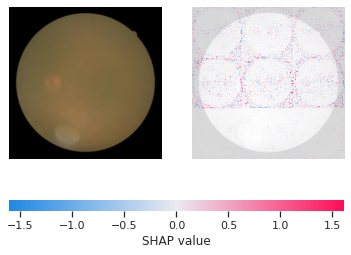

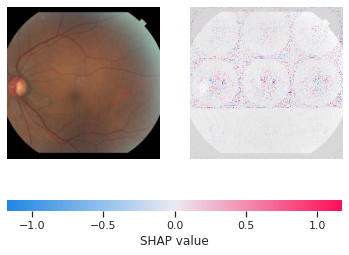

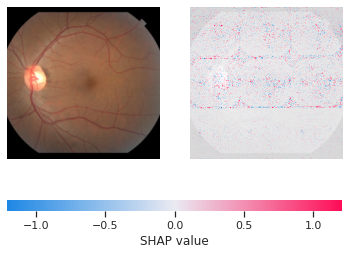

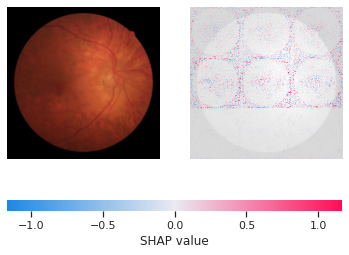

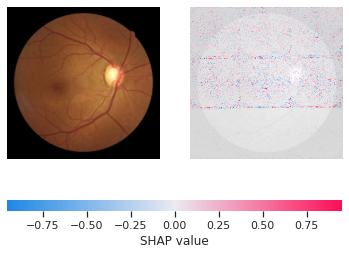

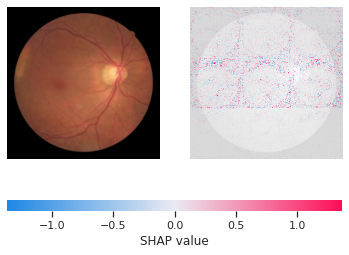

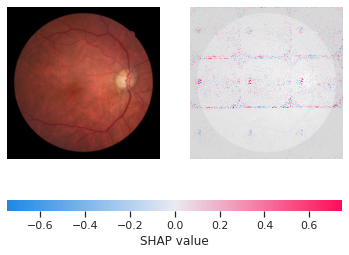

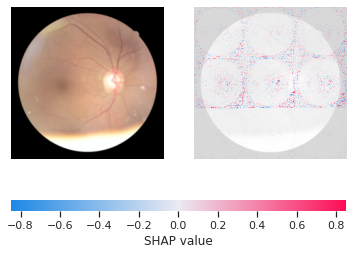

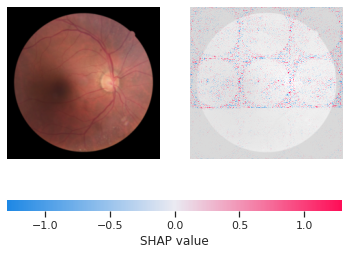

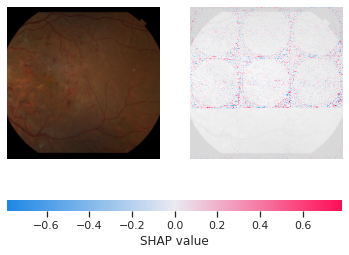

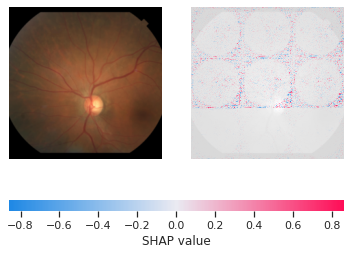

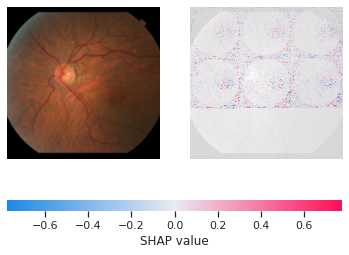

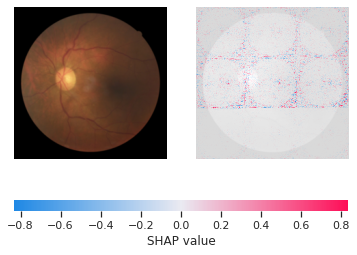

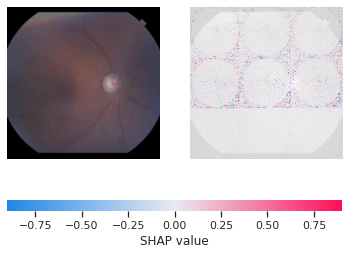

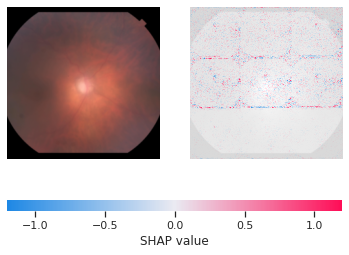

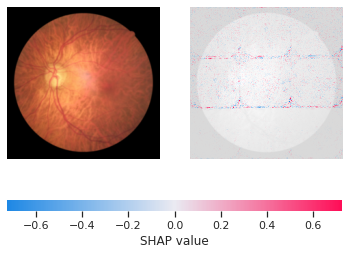

In [224]:
for i in range(len(list_of_tuples)):
    shap.image_plot(list_of_tuples[i][0],list_of_tuples[i][2], show=False)
    f = plt.gcf()
    f.savefig("../shap_images/model1_shap_" + str(i) + ".png")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

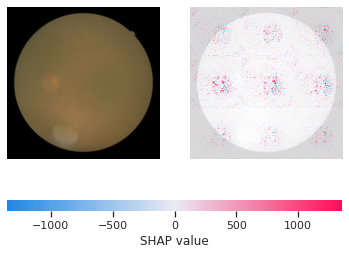

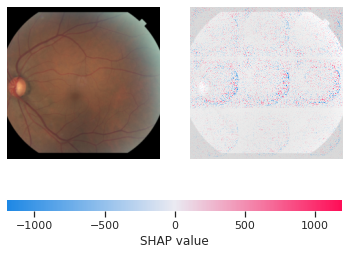

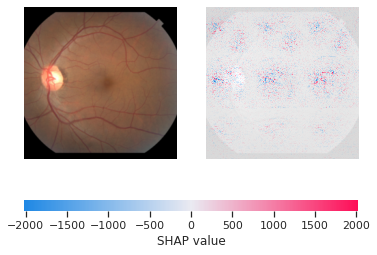

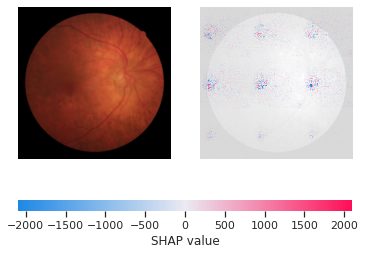

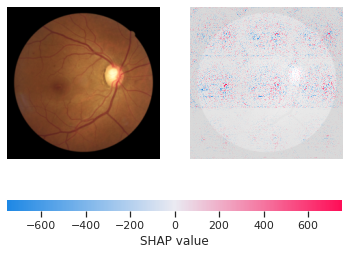

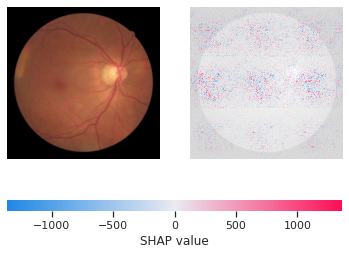

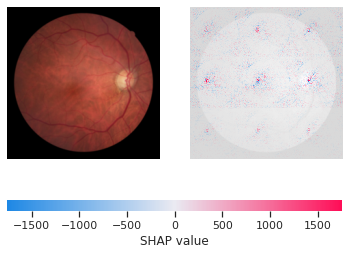

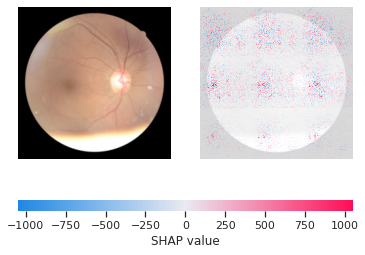

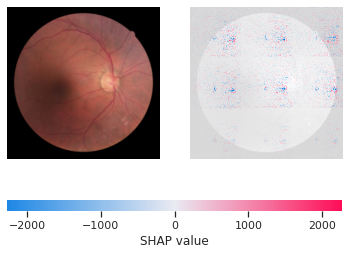

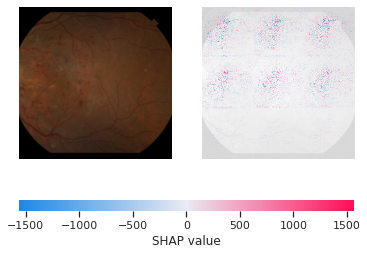

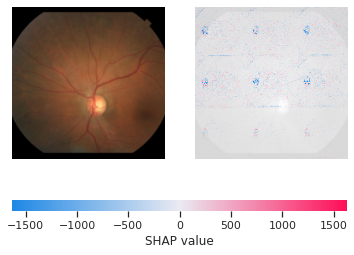

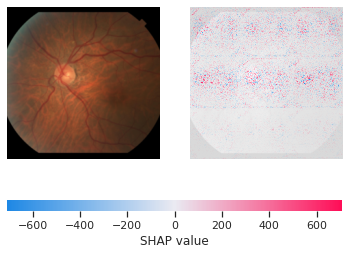

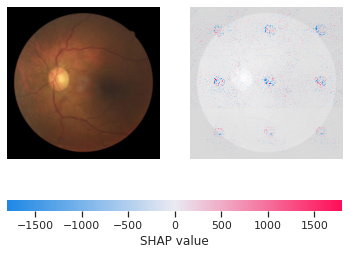

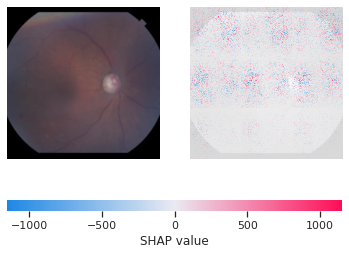

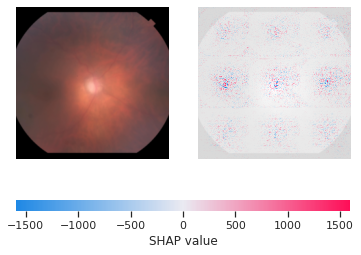

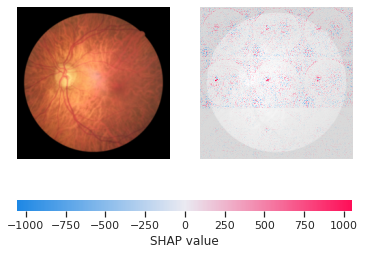

In [225]:
for i in range(len(list_of_tuples)):
    shap.image_plot(list_of_tuples[i][1],list_of_tuples[i][2], show=False)
    f = plt.gcf()
    f.savefig("../shap_images/model2_shap_" + str(i) + ".png")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


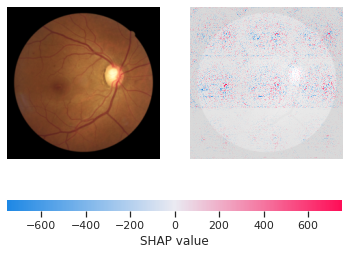

In [217]:
shap.image_plot(list_of_tuples[idx][1],list_of_tuples[idx][2])

In [238]:
shap.image_plot(photo1_numpy_1, photo1_shap_1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

IndexError: index 125 is out of bounds for axis 0 with size 125

Error in callback <function flush_figures at 0x7f73bebb13a0> (for post_execute):



KeyboardInterrupt



In [239]:
len(photo1_numpy_1)

125

In [240]:
len(photo1_shap_1)

157